desarrollar un calificador para la DB iris_dataset com particion 20/30 con clasifiacadores_LDA, k-NN(3), decision tree. mostrar fronteras de decision, mostras metricas

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
iris = load_iris(as_frame=True)

print("Características disponibles:")
print(iris.feature_names)

iris.frame.head()

Características disponibles:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
columnas = [
    "petal length (cm)",
    "petal width (cm)"
]

X = iris.data[columnas]
y = iris.target

nombres_clases = iris.target_names

print("Dimensiones de X:", X.shape)
print("\nCantidad de registros por especie:")
print(y.value_counts().sort_index())

Dimensiones de X: (150, 2)

Cantidad de registros por especie:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.40,
    stratify=y,
    random_state=42
)

print("Entrenamiento:")
print(
    y_train.value_counts()
    .sort_index()
    .rename(index=dict(enumerate(nombres_clases)))
)

print("\nPrueba:")
print(
    y_test.value_counts()
    .sort_index()
    .rename(index=dict(enumerate(nombres_clases)))
)

print("\nTotal entrenamiento:", len(X_train))
print("Total prueba:", len(X_test))

Entrenamiento:
target
setosa        20
versicolor    20
virginica     20
Name: count, dtype: int64

Prueba:
target
setosa        30
versicolor    30
virginica     30
Name: count, dtype: int64

Total entrenamiento: 60
Total prueba: 90


In [ ]:
modelos = {
    "LDA": LinearDiscriminantAnalysis(),

    "k-NN (k=3)": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=3)
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        random_state=42
    )
}

In [ ]:
resultados = []
predicciones = {}

for nombre, modelo in modelos.items():

    # Entrenamiento
    modelo.fit(X_train, y_train)

    # Predicción
    y_pred = modelo.predict(X_test)
    predicciones[nombre] = y_pred

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy,
        "Precision macro": precision,
        "Recall macro": recall,
        "F1 macro": f1
    })

    print("=" * 60)
    print(nombre)
    print("=" * 60)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=nombres_clases
        )
    )

LDA
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        30
  versicolor       0.90      0.93      0.92        30
   virginica       0.93      0.90      0.92        30

    accuracy                           0.94        90
   macro avg       0.94      0.94      0.94        90
weighted avg       0.94      0.94      0.94        90

k-NN (k=3)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        30
  versicolor       0.93      0.93      0.93        30
   virginica       0.93      0.93      0.93        30

    accuracy                           0.96        90
   macro avg       0.96      0.96      0.96        90
weighted avg       0.96      0.96      0.96        90

Decision Tree
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        30
  versicolor       0.78      0.97      0.87        30
   virginica       0.96      0.73      0.83   

In [ ]:
tabla_metricas = pd.DataFrame(resultados)

tabla_metricas.iloc[:, 1:] = tabla_metricas.iloc[:, 1:].round(4)

tabla_metricas

,Modelo,Accuracy,Precision macro,Recall macro,F1 macro
0,LDA,0.9444,0.9448,0.9444,0.9444
1,k-NN (k=3),0.9556,0.9556,0.9556,0.9556
2,Decision Tree,0.9000,0.9134,0.9000,0.8986


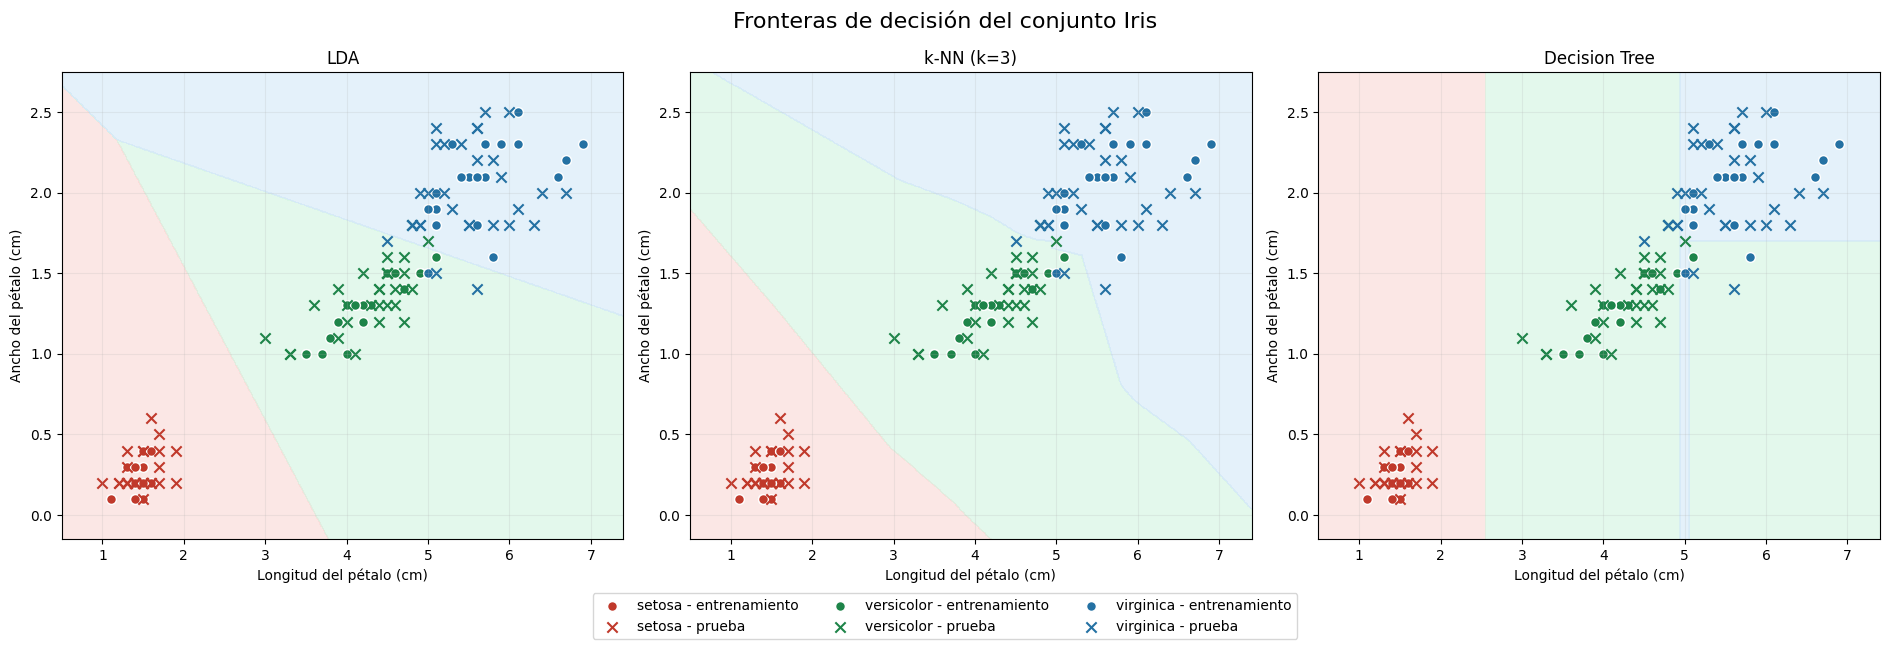

In [ ]:
colores_fondo = ListedColormap([
    "#FADBD8",
    "#D5F5E3",
    "#D6EAF8"
])

colores_puntos = [
    "#C0392B",
    "#1E8449",
    "#2471A3"
]

# Límites de la gráfica
x_min = X.iloc[:, 0].min() - 0.5
x_max = X.iloc[:, 0].max() + 0.5

y_min = X.iloc[:, 1].min() - 0.25
y_max = X.iloc[:, 1].max() + 0.25

# Crear una malla de puntos
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

malla = pd.DataFrame(
    np.c_[xx.ravel(), yy.ravel()],
    columns=X.columns
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(19, 6)
)

for ax, (nombre, modelo) in zip(axes, modelos.items()):

    # Clasificar cada punto de la malla
    Z = modelo.predict(malla)
    Z = Z.reshape(xx.shape)

    # Dibujar regiones de clasificación
    ax.contourf(
        xx,
        yy,
        Z,
        alpha=0.65,
        cmap=colores_fondo
    )

    for clase, etiqueta in enumerate(nombres_clases):

        mascara_train = y_train == clase
        mascara_test = y_test == clase

        # Datos de entrenamiento
        ax.scatter(
            X_train.loc[mascara_train, columnas[0]],
            X_train.loc[mascara_train, columnas[1]],
            color=colores_puntos[clase],
            marker="o",
            s=50,
            edgecolor="white",
            label=f"{etiqueta} - entrenamiento"
        )

        # Datos de prueba
        ax.scatter(
            X_test.loc[mascara_test, columnas[0]],
            X_test.loc[mascara_test, columnas[1]],
            color=colores_puntos[clase],
            marker="x",
            s=55,
            linewidth=1.5,
            label=f"{etiqueta} - prueba"
        )

    ax.set_title(nombre)
    ax.set_xlabel("Longitud del pétalo (cm)")
    ax.set_ylabel("Ancho del pétalo (cm)")
    ax.grid(alpha=0.2)

# Colocar una sola leyenda
handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.08)
)

plt.suptitle(
    "Fronteras de decisión del conjunto Iris",
    fontsize=16
)

plt.tight_layout()
plt.show()

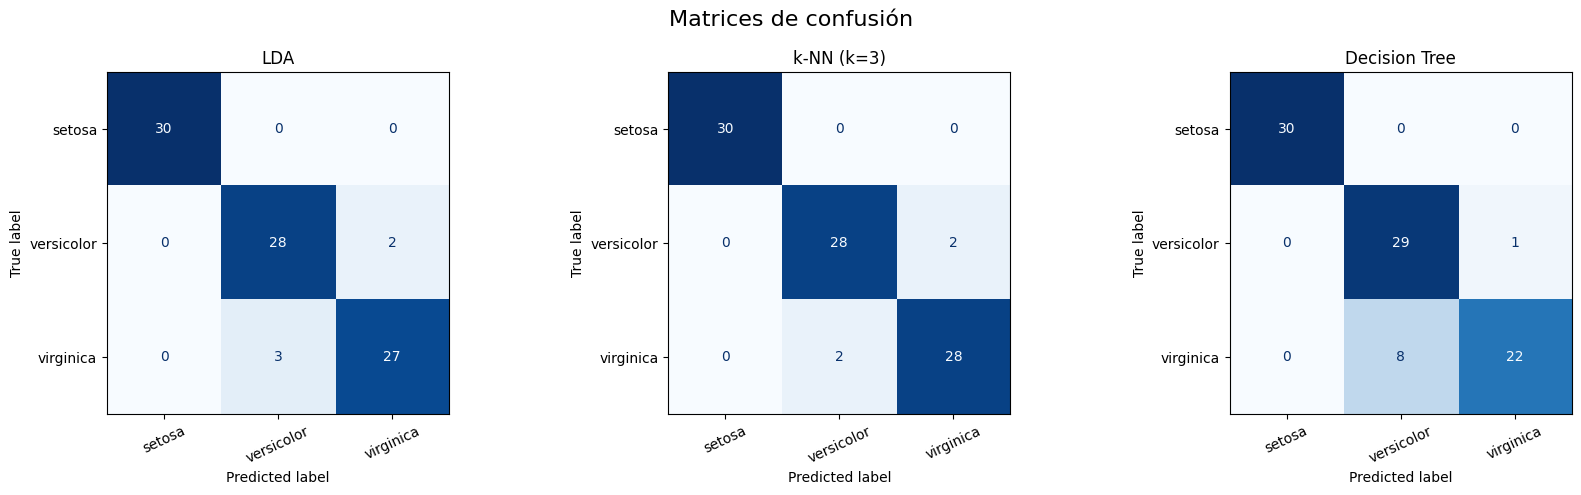

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5)
)

for ax, nombre in zip(axes, modelos.keys()):

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predicciones[nombre],
        display_labels=nombres_clases,
        cmap="Blues",
        colorbar=False,
        ax=ax
    )

    ax.set_title(nombre)
    ax.tick_params(axis="x", rotation=25)

plt.suptitle(
    "Matrices de confusión",
    fontsize=16
)

plt.tight_layout()
plt.show()

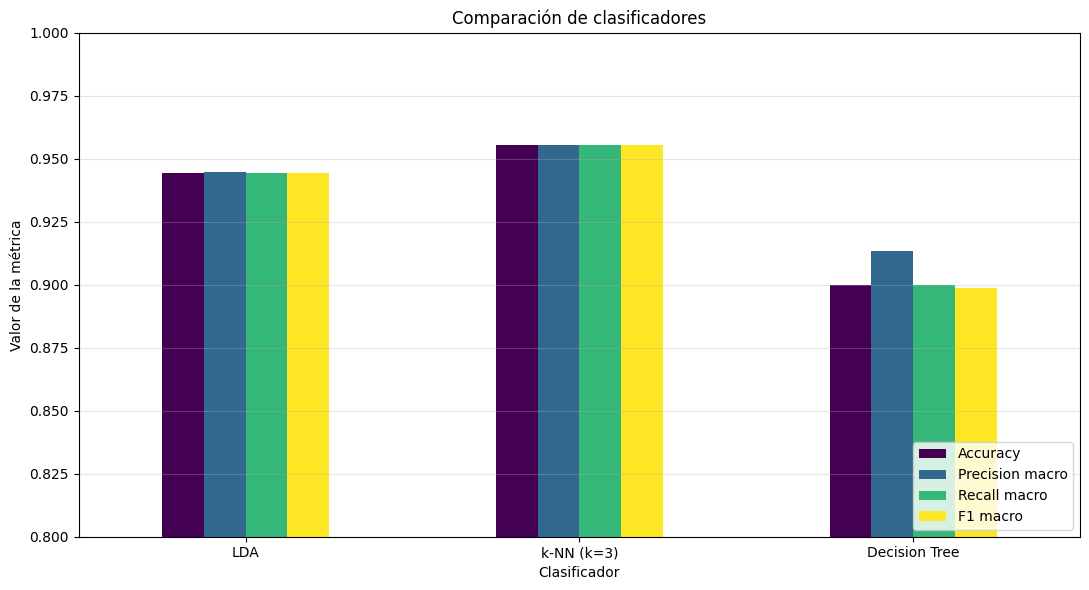

In [ ]:
metricas_grafica = tabla_metricas.set_index("Modelo")

metricas_grafica.plot(
    kind="bar",
    figsize=(11, 6),
    ylim=(0.80, 1.00),
    colormap="viridis"
)

plt.title("Comparación de clasificadores")
plt.xlabel("Clasificador")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()